# Overlaid Graphs

In this chapter, we have learned how to visualize data by drawing graphs. A common use of such visualizations is to compare two datasets. In this section, we will see how to *overlay* plots, that is, draw them in a single graphic on a common pair of axes.

For the overlay to make sense, the graphs that are being overlaid must represent the same variables and be measured in the same units.

To draw overlaid graphs using pandas and matplotlib, we explicitly call plotting functions multiple times on the same axes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

path_data = '../../../assets/data/'

## Overlaid Scatter Plots

The table `sons_heights` is part of a historical data set on the heights of parents and their children.

We load the data using pandas.


In [2]:
sons_heights = pd.read_csv(path_data + 'sons_heights.csv')
sons_heights

,father,mother,son
0,78.5,67.0,73.2
1,75.5,66.5,73.5
2,75.0,64.0,71.0
3,75.0,64.0,70.5
4,75.0,58.5,72.0
...,...,...,...
174,64.0,64.0,70.5
175,64.0,63.0,64.5
176,64.0,60.0,66.0
177,62.0,66.0,64.0


We now overlay scatter plots. The son's height is the common horizontal axis.


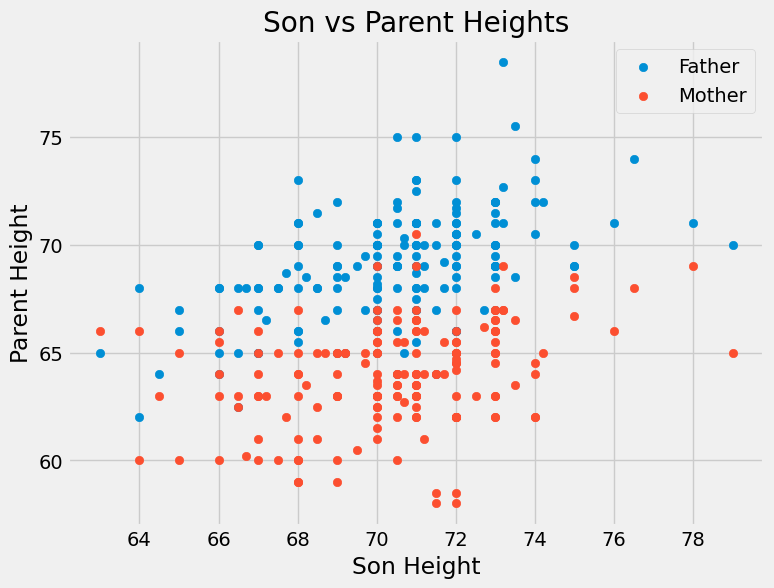

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(sons_heights['son'], sons_heights['father'], label='Father')
plt.scatter(sons_heights['son'], sons_heights['mother'], label='Mother')

plt.xlabel('Son Height')
plt.ylabel('Parent Height')
plt.title('Son vs Parent Heights')
plt.legend()
plt.show()

Each point represents a family trio. The plots show a positive association.


## Overlaid Line Plots

We now analyze Census data using pandas.


In [4]:
url = 'http://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.csv'

full_census = pd.read_csv(url)

us_pop = full_census[['SEX','AGE','POPESTIMATE2014','POPESTIMATE2019']]
us_pop = us_pop.rename(columns={'POPESTIMATE2014':'2014','POPESTIMATE2019':'2019'})

children = us_pop[(us_pop['SEX'] == 0) & (us_pop['AGE'] < 19)].drop(columns=['SEX'])
children

,AGE,2014,2019
0,0,3954787,3783052
1,1,3948891,3829599
2,2,3958711,3922044
3,3,4005928,3998665
4,4,4004032,4043323
5,5,4004576,4028281
6,6,4133372,4017227
7,7,4152666,4022319
8,8,4118349,4066194
9,9,4106068,4061874


Now we overlay line plots.


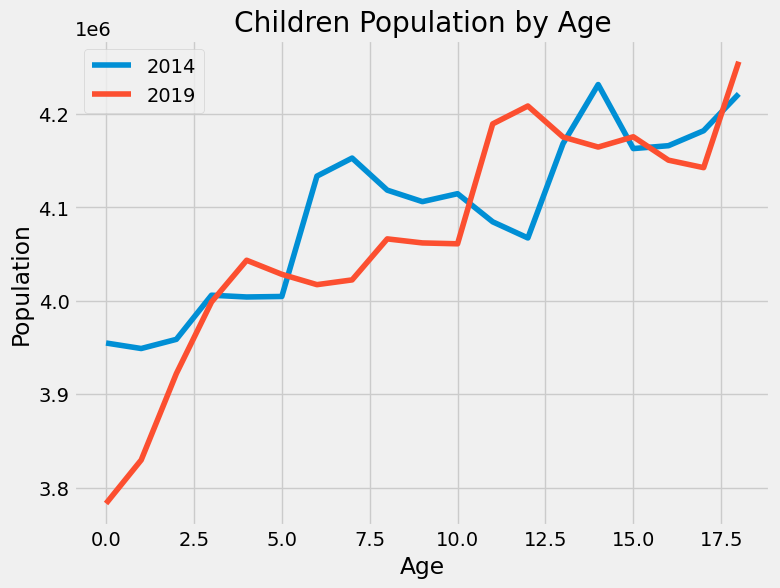

In [5]:
plt.figure(figsize=(8,6))

plt.plot(children['AGE'], children['2014'], label='2014')
plt.plot(children['AGE'], children['2019'], label='2019')

plt.xlabel('Age')
plt.ylabel('Population')
plt.title('Children Population by Age')
plt.legend()
plt.show()

The two graphs cross at several ages, indicating differences in population counts.


## Bar Charts

We load race/ethnicity data.


In [6]:
usa_ca = pd.read_csv(path_data + 'usa_ca_2019.csv')
usa_ca

,Ethnicity/Race,USA All,CA All,USA Children,CA Children
0,API,5.8,15.1,4.9,11.5
1,Black,12.2,5.3,13.4,4.9
2,Hispanic,18.5,39.5,25.6,52.1
3,White,60.1,36.4,50.0,25.5
4,Other,3.4,3.7,6.1,6.0


We overlay bar charts using horizontal offsets.


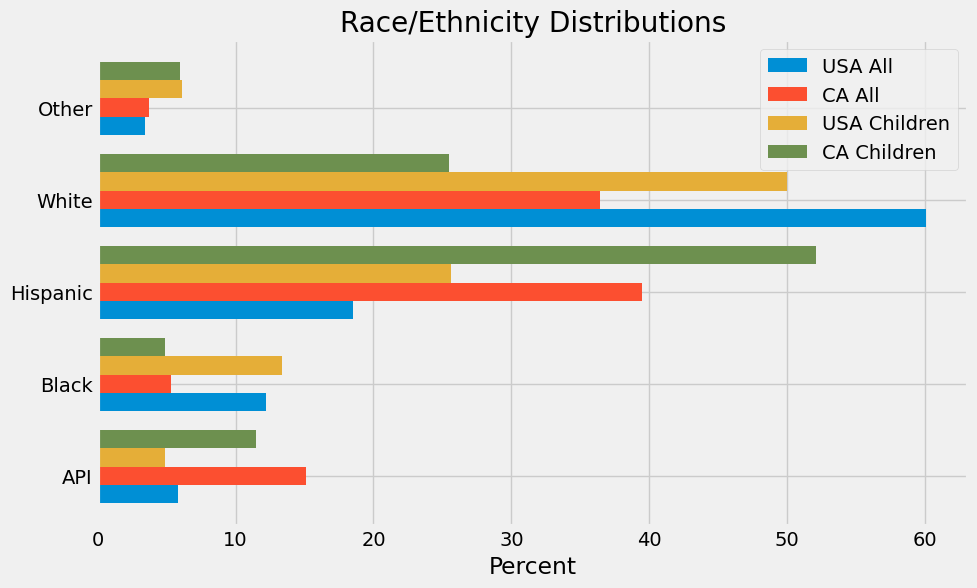

In [7]:
categories = usa_ca['Ethnicity/Race']
y = np.arange(len(categories))

plt.figure(figsize=(10,6))

plt.barh(y - 0.2, usa_ca['USA All'], height=0.2, label='USA All')
plt.barh(y, usa_ca['CA All'], height=0.2, label='CA All')
plt.barh(y + 0.2, usa_ca['USA Children'], height=0.2, label='USA Children')
plt.barh(y + 0.4, usa_ca['CA Children'], height=0.2, label='CA Children')

plt.yticks(y, categories)
plt.xlabel('Percent')
plt.title('Race/Ethnicity Distributions')
plt.legend()
plt.show()

To compare specific groups, select columns first.


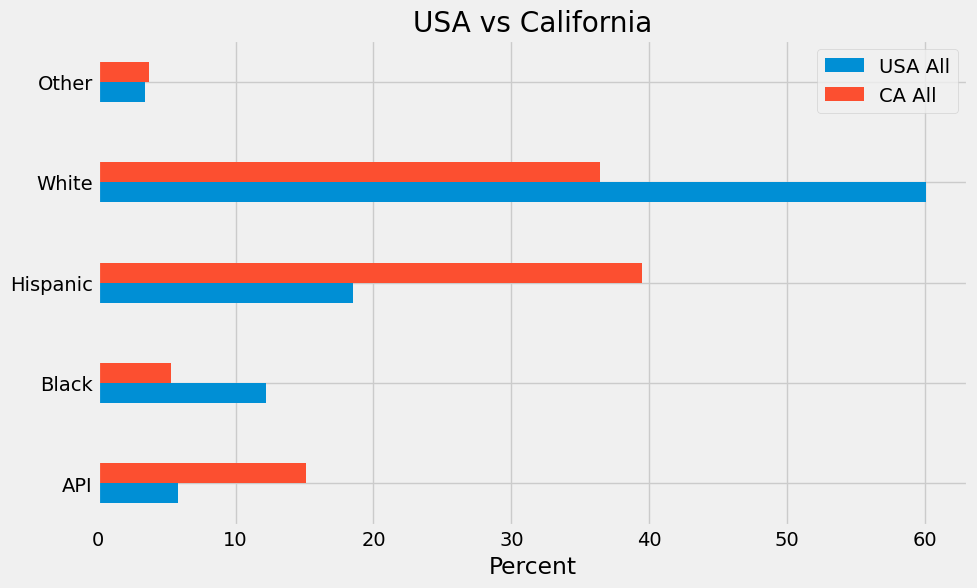

In [8]:
subset = usa_ca[['Ethnicity/Race', 'USA All', 'CA All']]

categories = subset['Ethnicity/Race']
y = np.arange(len(categories))

plt.figure(figsize=(10,6))

plt.barh(y - 0.1, subset['USA All'], height=0.2, label='USA All')
plt.barh(y + 0.1, subset['CA All'], height=0.2, label='CA All')

plt.yticks(y, categories)
plt.xlabel('Percent')
plt.title('USA vs California')
plt.legend()
plt.show()